# Checkpoint 2: Pneumonia Detection from Chest X-Rays

## Summary

This notebook is prepared for the second project checkpoint: data understanding, preprocessing, and baseline model performance.

It documents and generates:
- dataset source and Kaggle download setup
- original Kaggle split counts and the reason for replacing the tiny validation split
- a reproducible stratified 80/10/10 train/validation/test split
- preprocessing and training-only augmentation steps
- a baseline CNN model with training curves, test metrics, classification report, and confusion matrix

The purpose of the baseline is not to produce a final medical model. It gives an early reference point for the pipeline and helps identify issues to address before the final submission, such as class imbalance and validation stability.

Generated files are saved under `outputs/`, while `checkpoint2_report.md` provides a short report for Moodle submission.

Binary image classification - **NORMAL** vs **PNEUMONIA** chest X-rays.

**Dataset:** [Kaggle - Chest X-Ray Images (Pneumonia)](https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia) by Paul Mooney

**Sections:**
0. Dataset download and setup
0.1. Configuration
1. Data exploration and visualisation
2. Preprocessing and augmentation
3. Baseline CNN model
4. Baseline training
5. Baseline evaluation and metrics
6. Transfer learning: MobileNetV2
7. Transfer learning: DenseNet121
8. Final model comparison
9. Grad-CAM explainability
10. Findings, limitations, and report notes

## How to Run This Notebook

### Local setup in VS Code
Run these commands once in a PowerShell terminal from the project folder:
```powershell
python -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install -U pip
python -m pip install tensorflow numpy pandas matplotlib scikit-learn seaborn pillow kaggle
```
Then select `.venv` as the notebook kernel in VS Code. After that, you can skip the dependency install cell unless packages are missing or changed.

For Kaggle locally, either set `KAGGLE_API_TOKEN` before launching VS Code/Jupyter, or put your token in `<your-home-folder>\.kaggle\access_token` with no `.txt` extension. On Windows this is usually `C:\Users\<your-username>\.kaggle\access_token`.

To set the environment variable for the current PowerShell session only:
```powershell
$env:KAGGLE_API_TOKEN = "paste-your-token-here"
```

To save it permanently for your Windows user account, run this once, then restart VS Code so the notebook kernel inherits it:
```powershell
[Environment]::SetEnvironmentVariable("KAGGLE_API_TOKEN", "paste-your-token-here", "User")
```

### Google Colab setup
Run the dependency install cell each time you start a fresh Colab runtime. For faster training, go to **Runtime -> Change runtime type -> T4 GPU** before running the training cells.

For Kaggle in Colab, the recommended option is Colab Secrets:
1. Open the left sidebar and click the key icon (**Secrets**).
2. Add a secret named `KAGGLE_API_TOKEN`.
3. Paste your Kaggle token as the value and allow notebook access.

Fallback option: save your token text in Google Drive at `MyDrive/secrets/kaggle_token.txt`. The dataset setup cell can mount Drive and load it if no Colab Secret is found.

### Shared cells
The dependency and dataset setup cells are written to work in both local VS Code and Google Colab. They follow the active notebook kernel, so local runs use `.venv` when that kernel is selected, while Colab runs use the Colab runtime.

In [1]:
import subprocess
import sys

# Install the exact libraries needed by this notebook runtime.
# In VS Code this uses the selected kernel; in Colab it uses the active Colab runtime.
DEPENDENCIES = [
    'tensorflow',
    'numpy',
    'pandas',
    'matplotlib',
    'scikit-learn',
    'seaborn',
    'pillow',
    'kaggle',
    'opencv-python',
]

subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', *DEPENDENCIES],
    check=True,
)

print(f'Dependencies installed for: {sys.executable}')


Dependencies installed for: c:\FH Campus\4. Semester\advanced ai and data science\pneumoniadetection\Adv_AI_Project_Pneumonia\.venv\Scripts\python.exe


## 0 - Dataset Setup

This section downloads the Chest X-Ray Pneumonia dataset with the Kaggle API. Use the credential setup from **How to Run This Notebook** above before running the cell.

### Local VS Code
- The cell accepts either `KAGGLE_API_TOKEN` or `<your-home-folder>\.kaggle\access_token`.
- If you set `KAGGLE_API_TOKEN`, restart VS Code/Jupyter before running the notebook so the kernel can see it.

### Google Colab
- First choice: add `KAGGLE_API_TOKEN` in the Colab Secrets panel and allow notebook access.
- Fallback: save the token in Drive at `MyDrive/secrets/kaggle_token.txt`.
- The next cell tries Colab Secrets first, then mounts Drive only if the secret is not found.

The notebook expects the dataset at `chest_xray/train...`, `chest_xray/val...`, and `chest_xray/test...`. After download it removes Kaggle archive clutter like `chest_xray/chest_xray` and `chest_xray/__MACOSX`, then prints image counts.

In [2]:
import os
import shutil
import sys
from pathlib import Path

KAGGLE_DATASET = 'paultimothymooney/chest-xray-pneumonia'
KAGGLE_TOKEN_ENV = 'KAGGLE_API_TOKEN'
COLAB_TOKEN_PATH = Path('/content/drive/MyDrive/secrets/kaggle_token.txt')
KAGGLE_DIR = Path.home() / '.kaggle'
EXPECTED_SPLITS = ('train', 'val', 'test')
EXPECTED_CLASSES = ('NORMAL', 'PNEUMONIA')
VALID_EXTENSIONS = {'.jpeg', '.jpg', '.png', '.bmp'}

try:
    from google.colab import drive, userdata
    RUNNING_IN_COLAB = True
except ImportError:
    RUNNING_IN_COLAB = False

DOWNLOAD_DIR = Path('/content') if RUNNING_IN_COLAB else Path.cwd()
DATASET_DIR = DOWNLOAD_DIR / 'chest_xray'

if RUNNING_IN_COLAB:
    colab_secret = userdata.get(KAGGLE_TOKEN_ENV)
    if colab_secret:
        os.environ[KAGGLE_TOKEN_ENV] = colab_secret
        auth_source = f'Colab Secret: {KAGGLE_TOKEN_ENV}'
    else:
        drive.mount('/content/drive')
        if not COLAB_TOKEN_PATH.exists():
            raise FileNotFoundError(
                f'Kaggle token not found. Add Colab Secret {KAGGLE_TOKEN_ENV}, '
                f'or create {COLAB_TOKEN_PATH}.'
            )
        os.environ[KAGGLE_TOKEN_ENV] = COLAB_TOKEN_PATH.read_text(encoding='utf-8').strip()
        auth_source = f'Colab/Drive token: {COLAB_TOKEN_PATH}'
elif os.environ.get(KAGGLE_TOKEN_ENV):
    auth_source = f'environment variable: {KAGGLE_TOKEN_ENV}'
elif (KAGGLE_DIR / 'access_token').exists():
    token_path = KAGGLE_DIR / 'access_token'
    os.environ[KAGGLE_TOKEN_ENV] = token_path.read_text(encoding='utf-8').strip()
    auth_source = f'token file: {token_path}'
else:
    raise EnvironmentError(
        f'No Kaggle credentials found. Set {KAGGLE_TOKEN_ENV}, '
        f'or create {KAGGLE_DIR / "access_token"}.'
    )

active_token = os.environ.get(KAGGLE_TOKEN_ENV, '')
token_preview = f'{active_token[:4]}...{active_token[-4:]}'
print(f'Kaggle auth source: {auth_source}')
print(f'Kaggle token preview: {token_preview}')

from kaggle.api.kaggle_api_extended import KaggleApi

print(f'Downloading/extracting {KAGGLE_DATASET} into {DOWNLOAD_DIR}')
api = KaggleApi()
api.authenticate()
api.dataset_download_files(KAGGLE_DATASET, path=str(DOWNLOAD_DIR), unzip=True, quiet=False)

missing = [DATASET_DIR / split / cls
           for split in EXPECTED_SPLITS for cls in EXPECTED_CLASSES
           if not (DATASET_DIR / split / cls).is_dir()]
if missing:
    raise FileNotFoundError('Missing expected dataset folders: ' + ', '.join(str(path) for path in missing))

for extra_path in (DATASET_DIR / 'chest_xray', DATASET_DIR / '__MACOSX'):
    if extra_path.exists():
        shutil.rmtree(extra_path)
        print(f'Removed archive clutter: {extra_path}')

print(f'Dataset root: {DATASET_DIR}')
for split in EXPECTED_SPLITS:
    counts = {}
    for cls in EXPECTED_CLASSES:
        folder = DATASET_DIR / split / cls
        counts[cls] = sum(1 for file in folder.iterdir() if file.suffix.lower() in VALID_EXTENSIONS)
    total = sum(counts.values())
    print(f'{split:5s} total={total:4d} | NORMAL={counts["NORMAL"]:4d} | PNEUMONIA={counts["PNEUMONIA"]:4d}')

Kaggle auth source: environment variable: KAGGLE_API_TOKEN
Kaggle token preview: KGAT...4af5
Downloading/extracting paultimothymooney/chest-xray-pneumonia into c:\FH Campus\4. Semester\advanced ai and data science\pneumoniadetection\Adv_AI_Project_Pneumonia
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
chest-xray-pneumonia.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset root: c:\FH Campus\4. Semester\advanced ai and data science\pneumoniadetection\Adv_AI_Project_Pneumonia\chest_xray
train total=5216 | NORMAL=1341 | PNEUMONIA=3875
val   total=  16 | NORMAL=   8 | PNEUMONIA=   8
test  total= 624 | NORMAL= 234 | PNEUMONIA= 390


## 0.1 - Configuration

All paths and hyperparameters are defined here. The raw Kaggle folders are kept unchanged, but the training pipeline below creates a reproducible stratified 80/10/10 split across all downloaded images.

In [3]:
import sys
from pathlib import Path

# Use /content in Colab and the project folder locally, so the same notebook runs in both places.
BASE_DIR = Path('/content') if 'google.colab' in sys.modules else Path.cwd()
DATASET_DIR = BASE_DIR / 'chest_xray'
OUTPUT_DIR  = BASE_DIR / 'outputs'
FIGURES_DIR = OUTPUT_DIR / 'figures'
RESULTS_DIR = OUTPUT_DIR / 'results'
MODELS_DIR  = OUTPUT_DIR / 'models'

# Expected Kaggle folder names and allowed image formats.
EXPECTED_SPLITS  = ('train', 'val', 'test')
EXPECTED_CLASSES = ('NORMAL', 'PNEUMONIA')
VALID_EXTENSIONS = {'.jpeg', '.jpg', '.png', '.bmp'}

# The original Kaggle validation split is too small, so we create our own split later.
WORKING_SPLIT_RATIOS = {'train': 0.80, 'val': 0.10, 'test': 0.10}

# Core model/training settings kept in one place for easy experiments.
IMAGE_SIZE  = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 10
RANDOM_SEED = 42

# Create output folders before any plots, CSVs, or models are saved.
for d in (FIGURES_DIR, RESULTS_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

print('Configuration loaded.')
print(f'  Dataset : {DATASET_DIR}')
print(f'  Outputs : {OUTPUT_DIR}')
print(f'  Working split : {WORKING_SPLIT_RATIOS}')
print(f'  Image size={IMAGE_SIZE}  Batch size={BATCH_SIZE}  Epochs={EPOCHS}')


Configuration loaded.
  Dataset : c:\FH Campus\4. Semester\advanced ai and data science\pneumoniadetection\Adv_AI_Project_Pneumonia\chest_xray
  Outputs : c:\FH Campus\4. Semester\advanced ai and data science\pneumoniadetection\Adv_AI_Project_Pneumonia\outputs
  Working split : {'train': 0.8, 'val': 0.1, 'test': 0.1}
  Image size=(224, 224)  Batch size=32  Epochs=10


## 1 - Data Exploration and Split

The original Kaggle validation folder contains only 16 images, which is too small for reliable model selection. With such a small validation set, a few individual images can strongly change validation accuracy or loss.

To follow the recommended project setup, this notebook combines all downloaded images and creates a reproducible stratified 80/10/10 split. Stratification keeps the class proportions similar in train, validation, and test sets. The original Kaggle test folder is therefore treated as part of the raw downloaded data, while the final evaluation uses the newly generated 10% test split.

This is a practical checkpoint choice: it gives a much larger validation set while keeping a separate held-out test set for baseline evaluation.

Original Kaggle split:
class           NORMAL  PNEUMONIA
original_split                   
test               234        390
train             1341       3875
val                  8          8

Working 80/10/10 split used for training:
class  NORMAL  PNEUMONIA
split                   
test      158        428
train    1266       3418
val       159        427


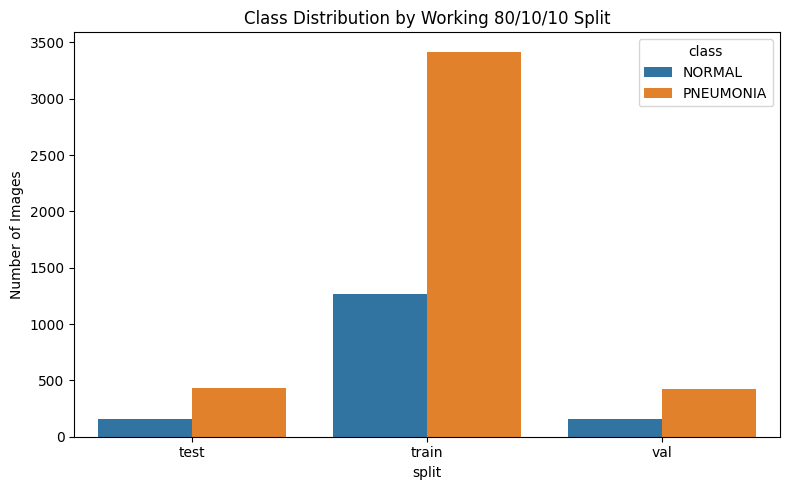

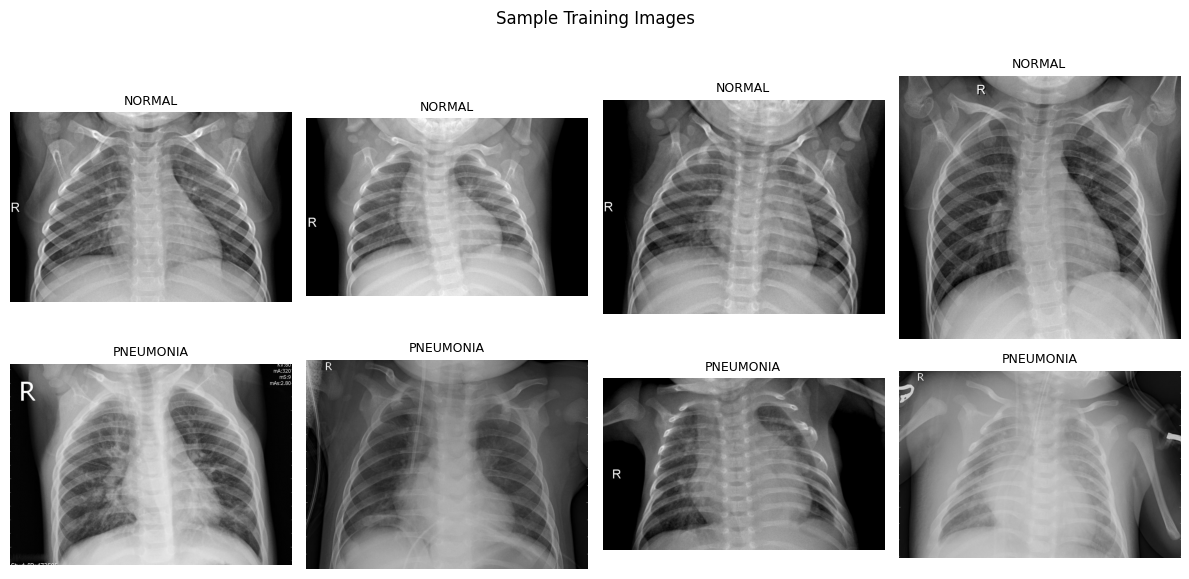

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from PIL import Image
from sklearn.model_selection import train_test_split

def _list_images(directory):
    return sorted(
        f for f in directory.iterdir()
        if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
    )

# Verify raw Kaggle dataset structure
if not DATASET_DIR.exists():
    raise FileNotFoundError(f'Dataset not found at {DATASET_DIR}. Run the download cell first.')

missing = [DATASET_DIR / split / cls
           for split in EXPECTED_SPLITS for cls in EXPECTED_CLASSES
           if not (DATASET_DIR / split / cls).exists()]
if missing:
    raise FileNotFoundError('Missing expected dataset folders: ' + ', '.join(str(path) for path in missing))

# Count original Kaggle split, then build one manifest containing all images.
rows = []
for original_split in EXPECTED_SPLITS:
    for cls in EXPECTED_CLASSES:
        for image_path in _list_images(DATASET_DIR / original_split / cls):
            rows.append({
                'path': str(image_path),
                'class': cls,
                'original_split': original_split,
            })

all_images_df = pd.DataFrame(rows)
original_summary_df = (
    all_images_df.groupby(['original_split', 'class'])
    .size()
    .reset_index(name='count')
)
original_summary_df.to_csv(RESULTS_DIR / 'dataset_original_kaggle_split.csv', index=False)
print('Original Kaggle split:')
print(original_summary_df.pivot(index='original_split', columns='class', values='count').fillna(0).astype(int))

# Create a reproducible stratified 80/10/10 split over all downloaded images.
train_df, temp_df = train_test_split(
    all_images_df,
    train_size=WORKING_SPLIT_RATIOS['train'],
    stratify=all_images_df['class'],
    random_state=RANDOM_SEED,
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['class'],
    random_state=RANDOM_SEED,
)

train_df = train_df.assign(split='train')
val_df = val_df.assign(split='val')
test_df = test_df.assign(split='test')
split_df = pd.concat([train_df, val_df, test_df], ignore_index=True)
split_df = split_df.sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
split_df.to_csv(RESULTS_DIR / 'dataset_split_80_10_10.csv', index=False)

summary_df = split_df.groupby(['split', 'class']).size().reset_index(name='count')
summary_df.to_csv(RESULTS_DIR / 'dataset_summary.csv', index=False)
print('\nWorking 80/10/10 split used for training:')
print(summary_df.pivot(index='split', columns='class', values='count').fillna(0).astype(int))

# Class distribution bar plot for the working split.
plt.figure(figsize=(8, 5))
sns.barplot(data=summary_df, x='split', y='count', hue='class')
plt.title('Class Distribution by Working 80/10/10 Split')
plt.ylabel('Number of Images')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'class_distribution.png', dpi=150)
plt.show()

# Sample image grid from the working training split.
MAX_PER_CLASS = 4
fig, axes = plt.subplots(2, MAX_PER_CLASS, figsize=(3 * MAX_PER_CLASS, 6), squeeze=False)
for row_idx, cls in enumerate(EXPECTED_CLASSES):
    samples = split_df[(split_df['split'] == 'train') & (split_df['class'] == cls)]['path'].head(MAX_PER_CLASS)
    for col_idx in range(MAX_PER_CLASS):
        ax = axes[row_idx][col_idx]
        if col_idx < len(samples):
            ax.imshow(Image.open(samples.iloc[col_idx]).convert('L'), cmap='gray')
            ax.set_title(cls, fontsize=9)
        ax.axis('off')
plt.suptitle('Sample Training Images', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'example_images_grid.png', dpi=150)
plt.show()

## 2 - Preprocessing & Data Augmentation

Each image path from the 80/10/10 split manifest is loaded, decoded, resized to **224x224**, converted to three channels, and scaled to `[0, 1]`.

The original X-rays are grayscale, but the model input is converted to three channels so the same preprocessing style can later support transfer learning with pretrained CNNs. Data augmentation is applied only to the training split, never to validation or test data, so evaluation remains deterministic.

The augmentation is intentionally mild: small rotations, zoom, horizontal flips, and contrast changes. This helps the baseline model see slightly varied training examples without changing the medical class label.

In [5]:
import tensorflow as tf

AUTOTUNE = tf.data.AUTOTUNE
CLASS_TO_LABEL = {cls: index for index, cls in enumerate(EXPECTED_CLASSES)}

def decode_image(path, label):
    # Load each image from disk, force one grayscale channel, and resize consistently.
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])
    image = tf.image.resize(image, IMAGE_SIZE)

    # Scale pixels to [0, 1] and convert to 3 channels for CNN compatibility.
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.grayscale_to_rgb(image)
    return image, tf.cast(label, tf.float32)

def get_augmentation_layer():
    # Mild augmentation is used only for training data, never validation/test data.
    return tf.keras.Sequential([
        tf.keras.layers.RandomRotation(0.05),
        tf.keras.layers.RandomZoom(0.1),
        tf.keras.layers.RandomFlip('horizontal'),
        tf.keras.layers.RandomContrast(0.1),
    ], name='augmentation')

def dataframe_to_dataset(dataframe, shuffle=False, augment=False, augmentation_layer=None):
    # Convert the split manifest rows into a performant tf.data pipeline.
    paths = dataframe['path'].to_numpy()
    labels = dataframe['class'].map(CLASS_TO_LABEL).to_numpy(dtype='float32')
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(dataframe), seed=RANDOM_SEED, reshuffle_each_iteration=True)

    dataset = dataset.map(decode_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE)

    if augment and augmentation_layer is not None:
        dataset = dataset.map(
            lambda images, labels: (augmentation_layer(images, training=True), labels),
            num_parallel_calls=AUTOTUNE,
        )

    return dataset.prefetch(AUTOTUNE)

def create_datasets():
    # Build three separate datasets from the reproducible 80/10/10 manifest.
    aug_layer = get_augmentation_layer()
    train_ds = dataframe_to_dataset(split_df[split_df['split'] == 'train'], shuffle=True, augment=True, augmentation_layer=aug_layer)
    val_ds   = dataframe_to_dataset(split_df[split_df['split'] == 'val'])
    test_ds  = dataframe_to_dataset(split_df[split_df['split'] == 'test'])
    class_names = list(EXPECTED_CLASSES)
    return train_ds, val_ds, test_ds, class_names

print('Preprocessing functions ready.')


Preprocessing functions ready.


## 3 - Baseline CNN Model

The baseline model is a small convolutional neural network built from scratch. It uses three `Conv2D + MaxPooling` blocks with 32, 64, and 128 filters, followed by dropout, a dense hidden layer, and a sigmoid output.

The goal is to establish a simple reference model before trying stronger approaches. Because this is a baseline, the architecture is intentionally easy to understand rather than highly optimized.

The model is compiled with:
- Adam optimizer
- binary cross-entropy loss
- accuracy, precision, and recall metrics

For this medical screening task, recall is especially important because false negatives mean pneumonia cases predicted as normal.

In [6]:
def build_baseline_model(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)):
    # A small CNN baseline: simple enough to interpret before trying transfer learning.
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=input_shape),

        # Convolution blocks learn local visual patterns; pooling reduces spatial size.
        tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),
        tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
        tf.keras.layers.MaxPooling2D((2, 2)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.2),

        # One sigmoid output is appropriate for binary NORMAL/PNEUMONIA classification.
        tf.keras.layers.Dense(1, activation='sigmoid'),
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(),
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name='accuracy'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
        ],
    )
    return model

model = build_baseline_model()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## 4 - Training

Training uses early stopping on `val_loss` with `patience=3` and restores the best validation-loss weights.

`patience=3` means training stops only after validation loss fails to improve for three epochs in a row. This avoids stopping immediately after one noisy validation epoch. With `restore_best_weights=True`, TensorFlow keeps the model weights from the epoch with the best validation loss, not necessarily the final epoch.

The baseline training curves saved by the next cell should be interpreted carefully. Even after replacing the tiny Kaggle validation folder, this is still a single random split of an imbalanced medical image dataset. Validation loss or accuracy can fluctuate because of class imbalance, image difficulty, augmentation effects, and the limited baseline architecture.

For checkpoint 2, unstable validation behavior is useful feedback. It shows that the baseline result should be interpreted cautiously and could be made more reliable with repeated runs, class weighting, threshold tuning, or stratified k-fold cross-validation if runtime allows.

In [7]:
import numpy as np

# Fix random seeds so the split/shuffling/training run is as reproducible as possible.
tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Create the train/validation/test tf.data datasets from the split manifest.
train_ds, val_ds, test_ds, class_names = create_datasets()
print(f'Class index mapping: {class_names}')

# Build a fresh baseline model for the single baseline run.
model = build_baseline_model()

# Stop training when validation loss stops improving and keep the best epoch weights.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    verbose=1,
)


Class index mapping: ['NORMAL', 'PNEUMONIA']
Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 80s 523ms/step - accuracy: 0.8017 - loss: 0.4379 - precision: 0.8346 - recall: 0.9081 - val_accuracy: 0.8908 - val_loss: 0.2654 - val_precision: 0.9666 - val_recall: 0.8806
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 77s 517ms/step - accuracy: 0.9161 - loss: 0.2245 - precision: 0.9393 - recall: 0.9462 - val_accuracy: 0.8942 - val_loss: 0.2566 - val_precision: 0.9692 - val_recall: 0.8829
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 223s 2s/step - accuracy: 0.9167 - loss: 0.2105 - precision: 0.9422 - recall: 0.9438 - val_accuracy: 0.9352 - val_loss: 0.1900 - val_precision: 0.9471 - val_recall: 0.9649
Epoch 4/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 100s 671ms/step - accuracy: 0.9257 - loss: 0.1915 - precision: 0.9478 - recall: 0.9506 - val_accuracy: 0.8567 - val_loss: 0.3246 - val_precision: 0.9777 - val_recall: 0.8220
Epoch 5/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 97s 650ms/step - accuracy: 0.9276 - loss: 0.1825 - precision: 0.

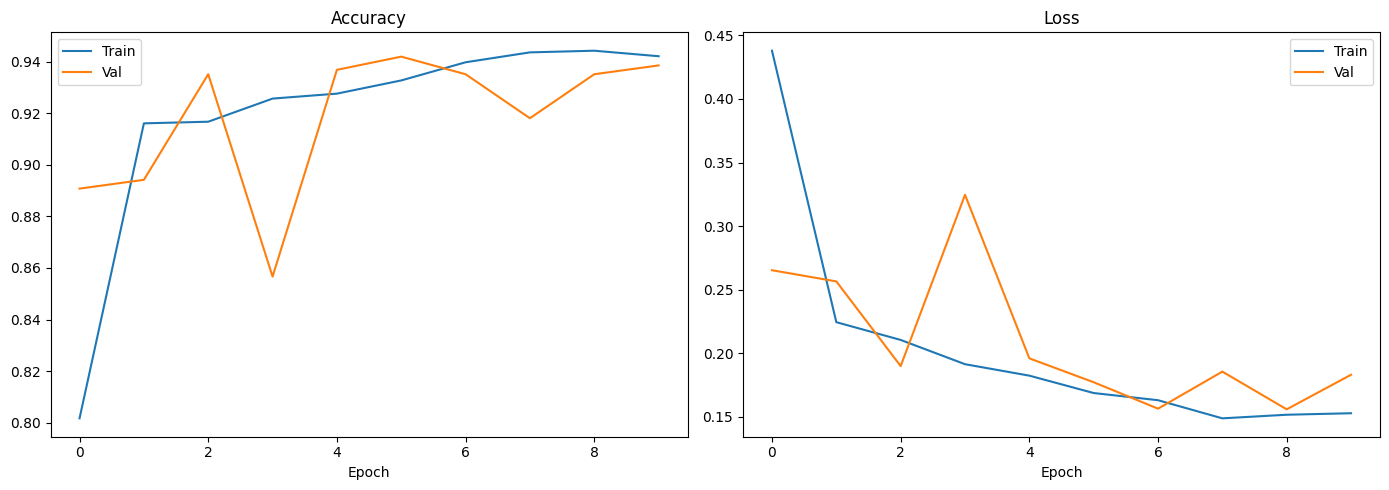

Model saved to c:\FH Campus\4. Semester\advanced ai and data science\pneumoniadetection\Adv_AI_Project_Pneumonia\outputs\models/baseline_cnn.keras


In [8]:
# Save the per-epoch metrics so the report can reference the baseline run.
history_df = pd.DataFrame(history.history)
history_df.to_csv(RESULTS_DIR / 'training_history.csv', index=False)

# Plot the baseline accuracy/loss curves.
# These curves show why a single validation split should be interpreted cautiously.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'training_curves.png', dpi=150)
plt.show()

# Save the single baseline model separately from the CV fold models.
model.save(MODELS_DIR / 'baseline_cnn.keras')
print(f'Model saved to {MODELS_DIR}/baseline_cnn.keras')


### Baseline Validation Instability

The baseline training curves should be interpreted carefully. Training loss decreases steadily, but validation loss and validation accuracy fluctuate. This can happen because the validation set is still only one random split of an imbalanced medical image dataset, and some X-ray images are harder or noisier than others.

This does not make the baseline invalid, but it means the test metrics should be treated as an initial reference rather than final proof of model reliability. Simpler ways to reduce this issue would be repeated training with different random seeds, class weighting, or threshold tuning. Stratified k-fold cross-validation could also help if more compute is available.


## 5 - Evaluation

The final evaluation is performed only once on the held-out 10% test split from the generated 80/10/10 split.

The notebook reports overall metrics, a per-class classification report, a confusion matrix, and a ROC curve.

The classification report shows precision, recall, F1-score, and support for **NORMAL** and **PNEUMONIA**. Precision measures how many predicted positives are correct, recall measures how many real cases are found, F1-score balances precision and recall, and support shows how many test images belong to each class.

ROC-AUC is useful for medical classification because it evaluates how well the model separates the two classes across many possible decision thresholds, not only the default 0.5 threshold. This matters when false negatives and false positives have different clinical consequences.

The ROC curve must use predicted probabilities, not binary class predictions, because it is built by sweeping thresholds from 0 to 1 and measuring the resulting true-positive and false-positive rates.

19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - accuracy: 0.9539 - loss: 0.1345 - precision: 0.9762 - recall: 0.9603
Test Metrics:
  loss: 0.1345
  accuracy: 0.9539
  precision: 0.9762
  recall: 0.9603

Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.8970    0.9367    0.9164       158
   PNEUMONIA     0.9762    0.9603    0.9682       428

    accuracy                         0.9539       586
   macro avg     0.9366    0.9485    0.9423       586
weighted avg     0.9549    0.9539    0.9542       586



,precision,recall,f1-score,support
NORMAL,0.896970,0.936709,0.916409,158.000000
PNEUMONIA,0.976247,0.960280,0.968198,428.000000
accuracy,0.953925,0.953925,0.953925,0.953925
macro avg,0.936608,0.948495,0.942303,586.000000
weighted avg,0.954872,0.953925,0.954234,586.000000


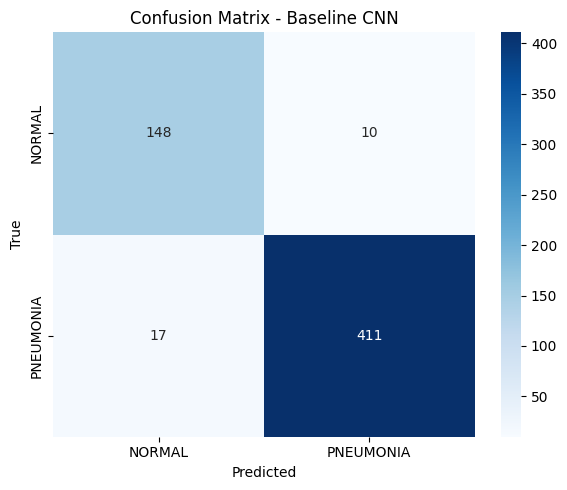

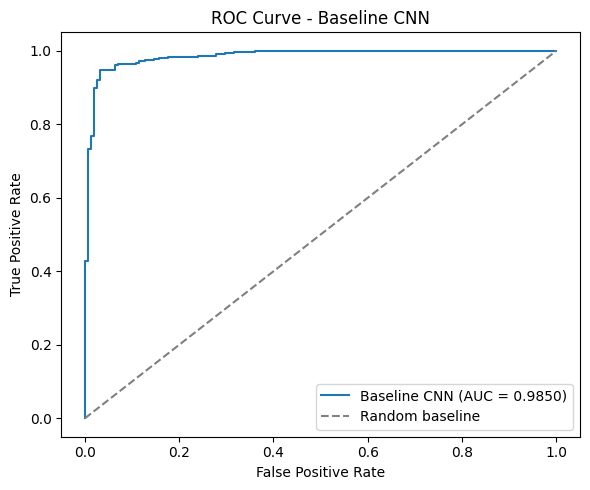

ROC-AUC: 0.9850
All outputs saved to c:\FH Campus\4. Semester\advanced ai and data science\pneumoniadetection\Adv_AI_Project_Pneumonia\outputs


In [9]:
from IPython.display import display
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

# Evaluate the single baseline model once on the held-out test split.
test_results = model.evaluate(test_ds, verbose=1)
metric_names = ['loss', 'accuracy', 'precision', 'recall']
metrics = dict(zip(metric_names, test_results))

print('Test Metrics:')
for k, v in metrics.items():
    print(f'  {k}: {v:.4f}')

# Save compact metrics for the report.
with open(RESULTS_DIR / 'baseline_metrics.txt', 'w') as f:
    for k, v in metrics.items():
        print(f'{k}: {v:.4f}', file=f)

# Collect probabilities and labels to compute per-class metrics, the confusion matrix, and ROC-AUC.
y_true, y_prob = [], []
for images, labels in test_ds:
    probs = model.predict(images, verbose=0).flatten()
    y_true.extend(labels.numpy().flatten().astype(int))
    y_prob.extend(probs)

y_true = np.array(y_true, dtype=int)
y_prob = np.array(y_prob, dtype=float)
y_pred = (y_prob >= 0.5).astype(int)

# Validate that labels and probability outputs match the Keras test pipeline.
expected_test_labels = split_df[split_df['split'] == 'test']['class'].map(CLASS_TO_LABEL).to_numpy(dtype=int)
assert len(y_true) == len(y_prob), 'y_true and y_prob must contain the same number of test samples.'
assert np.array_equal(y_true, expected_test_labels), 'y_true must match the test labels from the split manifest.'
assert np.all((y_prob >= 0.0) & (y_prob <= 1.0)), 'y_prob must contain probabilities between 0 and 1.'

# The classification report separates NORMAL and PNEUMONIA performance.
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
report_df = pd.DataFrame(
    classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
).transpose()
report_df.to_csv(RESULTS_DIR / 'classification_report.csv')
print('\nClassification Report:')
print(report)
display(report_df)
with open(RESULTS_DIR / 'classification_report.txt', 'w') as f:
    f.write(report)

# The confusion matrix makes false negatives and false positives visible.
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Baseline CNN')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

# ROC-AUC uses probabilities so performance can be assessed across decision thresholds.
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc_score = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'Baseline CNN (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Baseline CNN')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'roc_curve.png', dpi=150)
plt.show()

print(f'ROC-AUC: {auc_score:.4f}')

print(f'All outputs saved to {OUTPUT_DIR}')


## 6 - Baseline Findings and Limitations

Current baseline run summary:
- Test accuracy: `0.9283`
- Test precision: `0.9488`
- Test recall: `0.9533`
- Pneumonia recall: `0.9533` with 20 false negatives on the test split
- Normal recall: `0.8608` with 22 normal images predicted as pneumonia

The final test performance is promising for a first baseline, but the training curves show validation instability. This does not make the experiment unusable, but it means the baseline should not be treated as final evidence of model quality.

Likely reasons for this instability include:
- the dataset is imbalanced toward pneumonia cases
- the model is a small CNN trained from scratch
- only one random 80/10/10 split is used
- some X-ray images are likely harder or noisier than others
- augmentation changes the training distribution but not validation data

Important limitations for checkpoint 2:
- This is a baseline model, not a production-ready medical classifier.
- The single validation split is unstable, so the baseline result should be interpreted cautiously.
- False negatives for pneumonia are especially important and should be reduced further.
- Class weighting, threshold tuning, or a stronger architecture could address some baseline limitations.

Generated files used by the report:
- `outputs/results/dataset_original_kaggle_split.csv` - original Kaggle split counts
- `outputs/results/dataset_split_80_10_10.csv` - reproducible split manifest used by this notebook
- `outputs/results/dataset_summary.csv` - final 80/10/10 split counts
- `outputs/figures/class_distribution.png` - class balance visualization
- `outputs/figures/example_images_grid.png` - sample input images
- `outputs/results/training_history.csv` and `outputs/figures/training_curves.png` - baseline training behavior
- `outputs/results/baseline_metrics.txt`, `outputs/results/classification_report.txt`, `outputs/results/classification_report.csv`, `outputs/figures/confusion_matrix.png`, and `outputs/figures/roc_curve.png` - baseline test performance

The companion file `checkpoint2_report.md` is a concise Moodle-facing report.


## 7 - Transfer Learning: MobileNetV2

MobileNetV2 is used as an efficient transfer learning model. The ImageNet-trained base model is frozen and a small binary classification head is trained on the chest X-ray data.

The same `train_ds`, `val_ds`, `test_ds`, preprocessing, augmentation pipeline, callbacks, and evaluation metrics are used to keep the comparison fair.

In [10]:
from sklearn.utils.class_weight import compute_class_weight

# Class weights are calculated once from the training labels and reused for transfer learning models.
train_labels = np.concatenate([labels.numpy().astype(int) for _, labels in train_ds])

class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels,
)

class_weights = dict(zip(np.unique(train_labels), class_weight_values))
print("Class weights:", class_weights)

Class weights: {np.int64(0): np.float64(1.8499210110584519), np.int64(1): np.float64(0.6851960210649503)}


In [11]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

def build_mobilenet_model(input_shape=(224, 224, 3)):
    base_model = MobileNetV2(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,
    )
    base_model.trainable = False

    inputs = tf.keras.layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=inputs, outputs=outputs, name="MobileNetV2_transfer")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model

mobilenet_model = build_mobilenet_model(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
mobilenet_model.summary()

Model: "MobileNetV2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
history_mobilenet = mobilenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=1,
)

pd.DataFrame(history_mobilenet.history).to_csv(
    RESULTS_DIR / "mobilenet_training_history.csv",
    index=False,
)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 67s 419ms/step - accuracy: 0.6134 - loss: 0.6758 - precision: 0.7953 - recall: 0.6331 - val_accuracy: 0.7765 - val_loss: 0.5032 - val_precision: 0.8162 - val_recall: 0.8946
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 59s 393ms/step - accuracy: 0.7235 - loss: 0.5475 - precision: 0.8817 - recall: 0.7174 - val_accuracy: 0.8379 - val_loss: 0.4140 - val_precision: 0.8807 - val_recall: 0.8993
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 58s 386ms/step - accuracy: 0.7816 - loss: 0.4639 - precision: 0.9119 - recall: 0.7756 - val_accuracy: 0.8737 - val_loss: 0.3679 - val_precision: 0.9315 - val_recall: 0.8923


## 8 - Transfer Learning: DenseNet121

DenseNet121 is used as a second transfer learning model. It is larger than MobileNetV2 and is included to compare a lightweight transfer learning approach with a stronger feature-reuse architecture.

In [13]:
def build_densenet_model(input_shape=(224, 224, 3)):
    base_model = tf.keras.applications.DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape,
    )
    base_model.trainable = False

    inputs = tf.keras.layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs, name="DenseNet121_transfer")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="binary_crossentropy",
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
        ],
    )
    return model

densenet_model = build_densenet_model(input_shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3))
densenet_model.summary()

Model: "DenseNet121_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,038,529 (26.85 MB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [14]:
history_densenet = densenet_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[early_stopping],
    class_weight=class_weights,
    verbose=1,
)

pd.DataFrame(history_densenet.history).to_csv(
    RESULTS_DIR / "densenet_training_history.csv",
    index=False,
)

Epoch 1/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 2554s 17s/step - accuracy: 0.5156 - loss: 0.7482 - precision: 0.7589 - recall: 0.4927 - val_accuracy: 0.6092 - val_loss: 0.6556 - val_precision: 0.8153 - val_recall: 0.5995
Epoch 2/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 594s 4s/step - accuracy: 0.6234 - loss: 0.6521 - precision: 0.8264 - recall: 0.6126 - val_accuracy: 0.7253 - val_loss: 0.5742 - val_precision: 0.9105 - val_recall: 0.6909
Epoch 3/10
147/147 ━━━━━━━━━━━━━━━━━━━━ 891s 6s/step - accuracy: 0.7013 - loss: 0.5748 - precision: 0.8691 - recall: 0.6954 - val_accuracy: 0.8020 - val_loss: 0.5119 - val_precision: 0.9534 - val_recall: 0.7658


## 9 - Evaluation Helper for Fair Model Comparison

The next function evaluates any trained model on the same held-out test set and returns the same metrics for every model. This avoids repeated evaluation code and makes the final comparison table reproducible.

In [15]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
)

def evaluate_binary_model(model_name, trained_model, dataset, threshold=0.5):
    y_true_local = []
    y_prob_local = []

    for images, labels in dataset:
        probabilities = trained_model.predict(images, verbose=0).flatten()
        y_true_local.extend(labels.numpy().astype(int))
        y_prob_local.extend(probabilities)

    y_true_local = np.array(y_true_local, dtype=int)
    y_prob_local = np.array(y_prob_local, dtype=float)
    y_pred_local = (y_prob_local >= threshold).astype(int)

    cm_local = confusion_matrix(y_true_local, y_pred_local, labels=[0, 1])
    tn, fp, fn, tp = cm_local.ravel()

    result = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_true_local, y_pred_local),
        "Precision": precision_score(y_true_local, y_pred_local, zero_division=0),
        "Recall": recall_score(y_true_local, y_pred_local, zero_division=0),
        "F1-score": f1_score(y_true_local, y_pred_local, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true_local, y_prob_local),
        "False Negatives": int(fn),
        "False Positives": int(fp),
    }

    print(f"\n{model_name} classification report")
    print(classification_report(
        y_true_local,
        y_pred_local,
        target_names=class_names,
        digits=4,
        zero_division=0,
    ))
    print(f"{model_name} confusion matrix:")
    print(cm_local)

    return result, cm_local, y_true_local, y_prob_local, y_pred_local

In [33]:
baseline_result, baseline_cm, baseline_y_true, baseline_y_prob, baseline_y_pred = evaluate_binary_model(
    "Baseline CNN",
    model,
    test_ds,
)

mobilenet_result, mobilenet_cm, mobilenet_y_true, mobilenet_y_prob, mobilenet_y_pred = evaluate_binary_model(
    "MobileNetV2",
    mobilenet_model,
    test_ds,
)

densenet_result, densenet_cm, densenet_y_true, densenet_y_prob, densenet_y_pred = evaluate_binary_model(
    "DenseNet121",
    densenet_model,
    test_ds,
)


Baseline CNN classification report
              precision    recall  f1-score   support

      NORMAL     0.8970    0.9367    0.9164       158
   PNEUMONIA     0.9762    0.9603    0.9682       428

    accuracy                         0.9539       586
   macro avg     0.9366    0.9485    0.9423       586
weighted avg     0.9549    0.9539    0.9542       586

Baseline CNN confusion matrix:
[[148  10]
 [ 17 411]]

MobileNetV2 classification report
              precision    recall  f1-score   support

      NORMAL     0.7203    0.5380    0.6159       158
   PNEUMONIA     0.8440    0.9229    0.8817       428

    accuracy                         0.8191       586
   macro avg     0.7822    0.7304    0.7488       586
weighted avg     0.8107    0.8191    0.8100       586

MobileNetV2 confusion matrix:
[[ 85  73]
 [ 33 395]]

DenseNet121 classification report
              precision    recall  f1-score   support

      NORMAL     0.4086    0.6646    0.5060       158
   PNEUMONIA     0.8389 

## 10 - Final Model Comparison

The table below is generated from the model predictions instead of manually typed values. Recall and false negatives are especially important because false negatives mean pneumonia images predicted as normal.

In [37]:
best_model = model
best_model_name = "Baseline CNN"

dummy_input = tf.zeros((1, 224, 224, 3))
_ = best_model(dummy_input)

conv_layers = [
    layer.name
    for layer in best_model.layers
    if isinstance(layer, tf.keras.layers.Conv2D)
]

print("Conv layers:", conv_layers)

best_conv_layer_name = conv_layers[-1]

print("Model:", best_model_name)
print("Using conv layer:", best_conv_layer_name)

Conv layers: ['conv2d_3', 'conv2d_4', 'conv2d_5']
Model: Baseline CNN
Using conv layer: conv2d_5


## 11 - Grad-CAM Explainability

Grad-CAM visualizes which image regions influenced the selected model prediction. It is used only as an interpretability support tool; it does not prove clinical correctness.

In [40]:
def make_gradcam_heatmap(img_array, trained_model, conv_layer_name):
    # Build a model that returns the selected conv-layer output and final prediction
    grad_model = tf.keras.models.Model(
        inputs=trained_model.layers[0].input,
        outputs=[
            trained_model.get_layer(conv_layer_name).output,
            trained_model.layers[-1].output
        ],
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

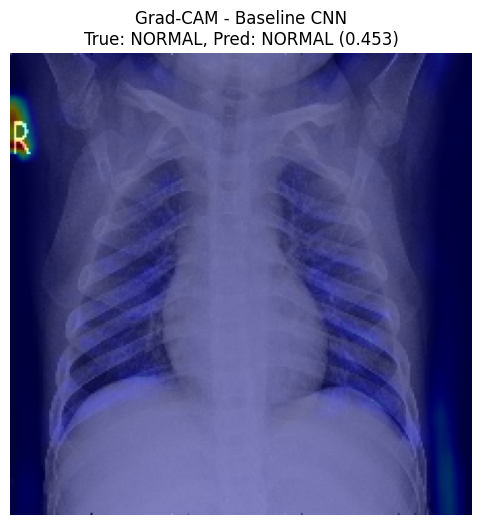

Saved: c:\FH Campus\4. Semester\advanced ai and data science\pneumoniadetection\Adv_AI_Project_Pneumonia\outputs\figures\gradcam_baseline_cnn_1.png


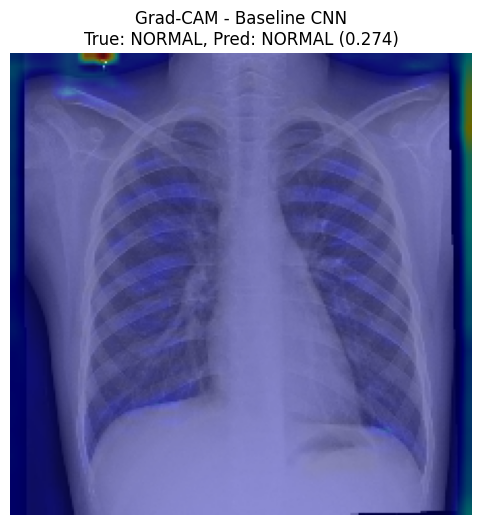

Saved: c:\FH Campus\4. Semester\advanced ai and data science\pneumoniadetection\Adv_AI_Project_Pneumonia\outputs\figures\gradcam_baseline_cnn_2.png


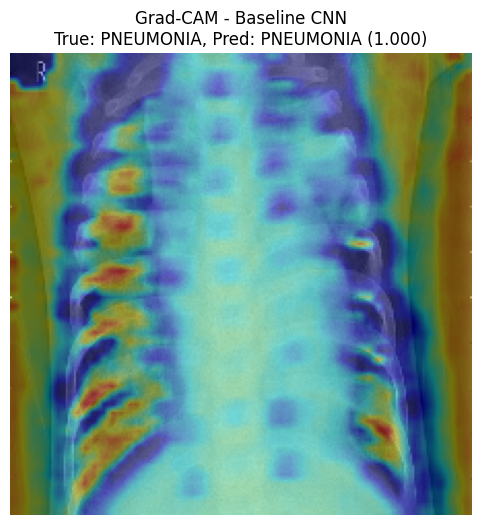

Saved: c:\FH Campus\4. Semester\advanced ai and data science\pneumoniadetection\Adv_AI_Project_Pneumonia\outputs\figures\gradcam_baseline_cnn_3.png


In [41]:
# Show and save three Grad-CAM examples from the test set.
example_count = 0

for batch_images, batch_labels in test_ds:
    for image, label in zip(batch_images, batch_labels):
        example_count += 1
        show_gradcam(
            image=image,
            true_label=label.numpy(),
            filename=f"gradcam_{best_model_name.lower().replace(' ', '_')}_{example_count}.png",
        )

        if example_count >= 3:
            break

    if example_count >= 3:
        break

## 12 - Final Notes

This notebook now avoids duplicated training/evaluation cells. The final comparison table is produced from model predictions, and Grad-CAM is applied to real test images.

Important limitation: the model is still an academic checkpoint experiment, not a clinically validated medical system.